In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sushantkr878/loan-approval-prediction-train-data/train (1).csv
/kaggle/input/datasets/sushantkr878/loan-approval-prediction-test-data/test.csv


In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sushantkr878/loan-approval-prediction-train-data/train (1).csv
/kaggle/input/datasets/sushantkr878/loan-approval-prediction-test-data/test.csv


In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from scipy import stats

# LOAD DATA

In [4]:
df = pd.read_csv('/kaggle/input/datasets/sushantkr878/loan-approval-prediction-train-data/train (1).csv')

# INITIAL EDA

In [5]:
df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [6]:
df.shape

(58645, 13)

In [7]:
df.columns

Index(['id', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')

In [8]:
df = df.drop(['id'] , axis = 1) 

In [9]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
loan_status                     int64
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  58645 non-null  int64  
 1   person_income               58645 non-null  int64  
 2   person_home_ownership       58645 non-null  object 
 3   person_emp_length           58645 non-null  float64
 4   loan_intent                 58645 non-null  object 
 5   loan_grade                  58645 non-null  object 
 6   loan_amnt                   58645 non-null  int64  
 7   loan_int_rate               58645 non-null  float64
 8   loan_percent_income         58645 non-null  float64
 9   cb_person_default_on_file   58645 non-null  object 
 10  cb_person_cred_hist_length  58645 non-null  int64  
 11  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 5.4+ MB


In [11]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

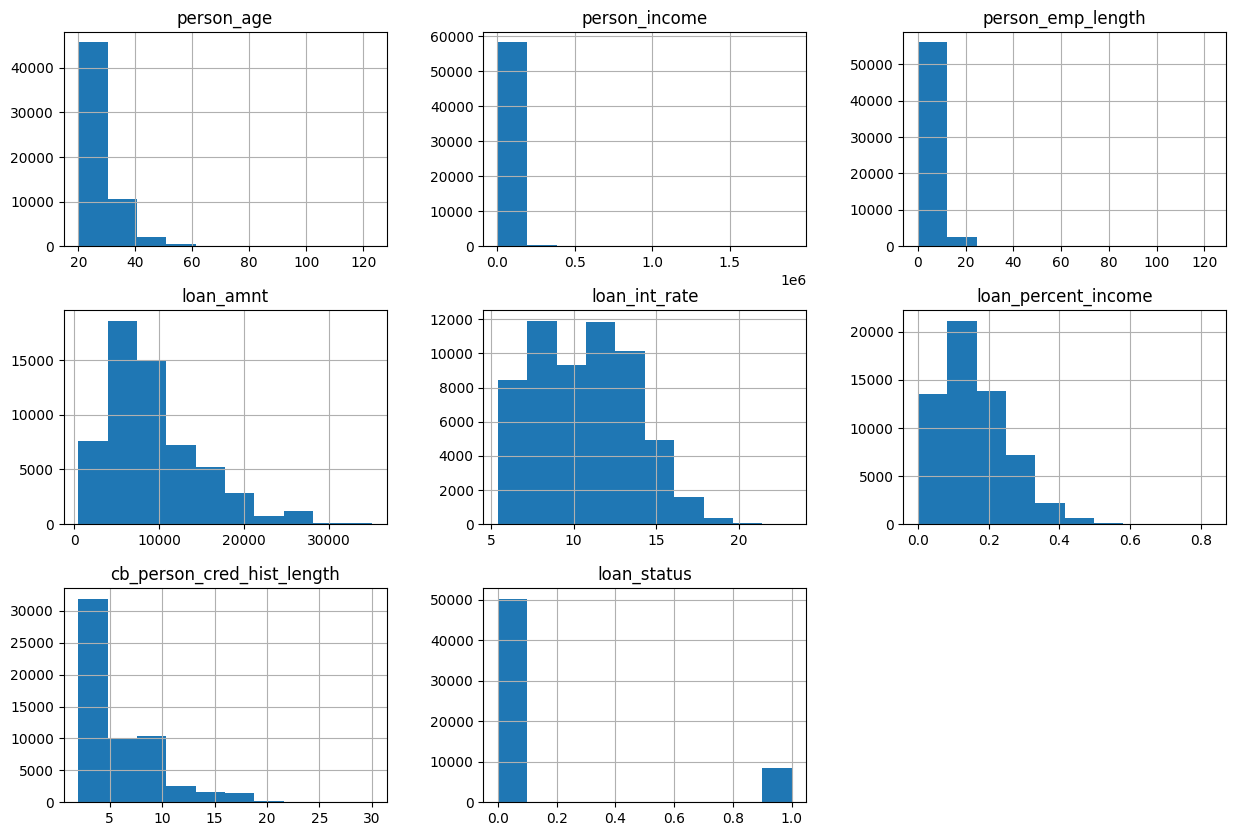

In [13]:
df.hist(figsize=(15,10))
plt.show()

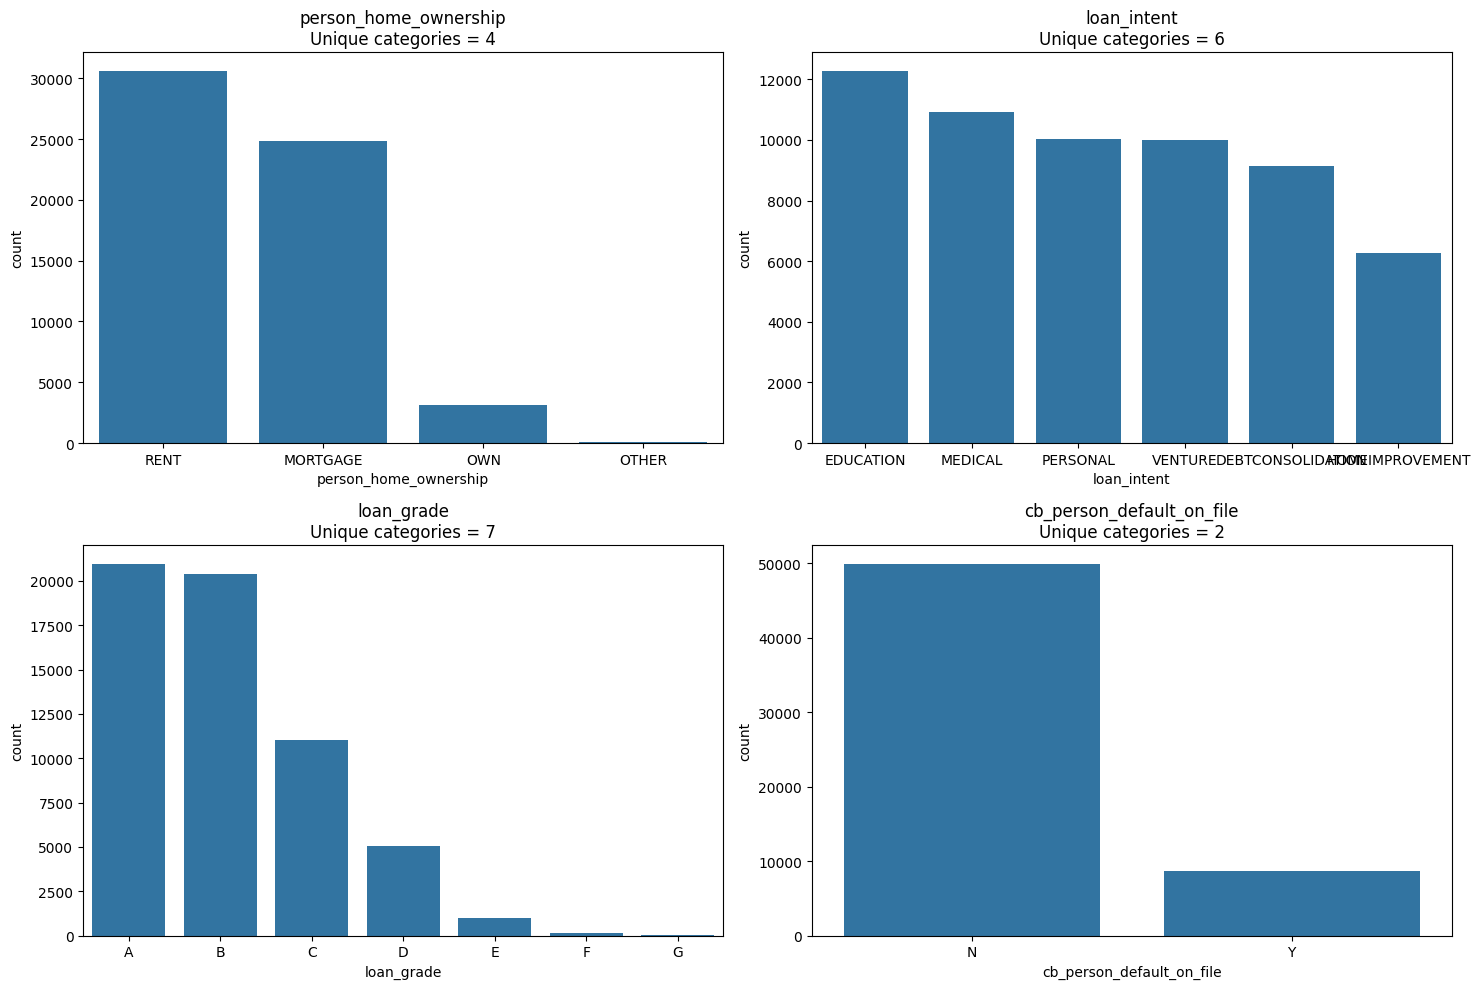

In [14]:
cat_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)

    order = df[col].value_counts().index

    sns.countplot(
        x=df[col],
        order=order
    )

    plt.title(
        f"{col}\nUnique categories = {df[col].nunique()}"
    )

plt.tight_layout()
plt.show()

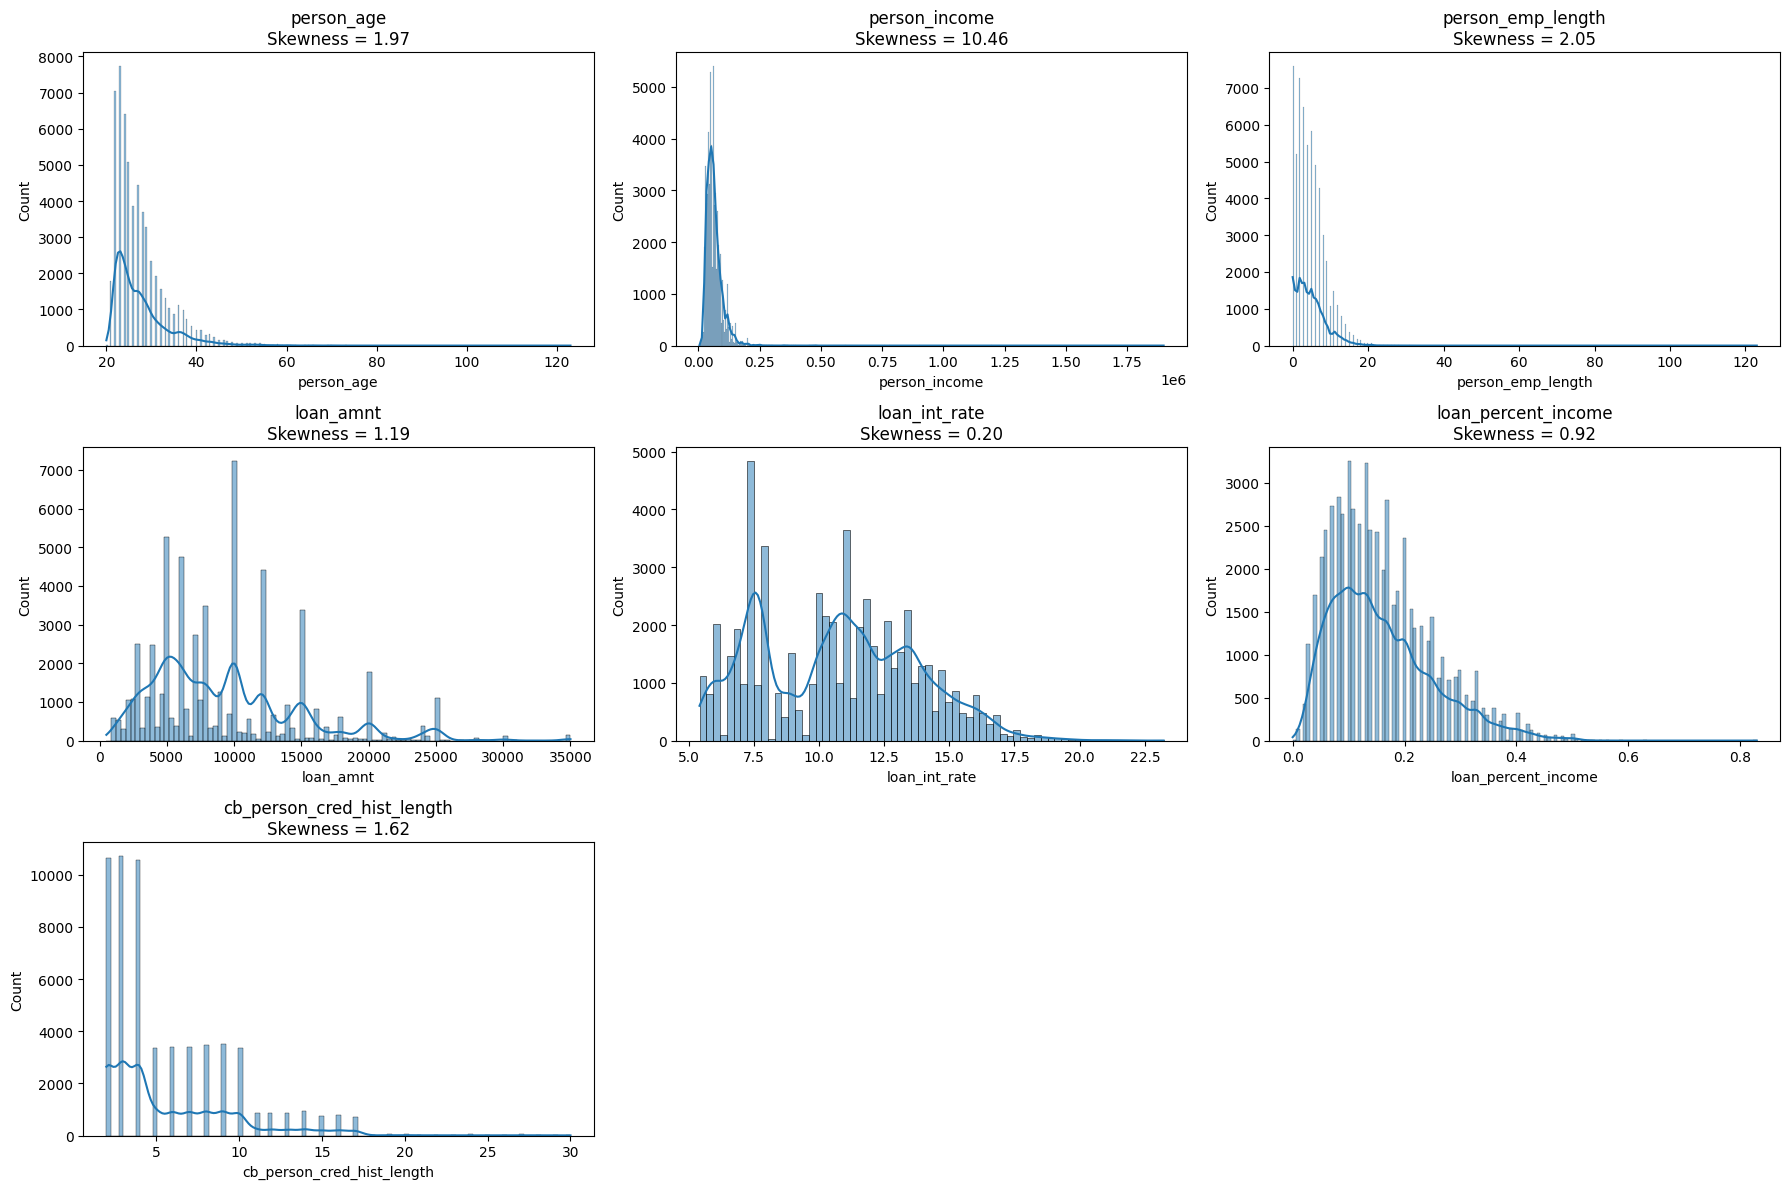

In [15]:
num_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)

    sns.histplot(df[col], kde=True)

    plt.title(
        f"{col}\nSkewness = {df[col].skew():.2f}"
    )

plt.tight_layout()
plt.show()

### Target Variable Analysis

In [16]:
# Target Variable - Loan Status

In [17]:
df['loan_status'].value_counts(dropna=False)

loan_status
0    50295
1     8350
Name: count, dtype: int64

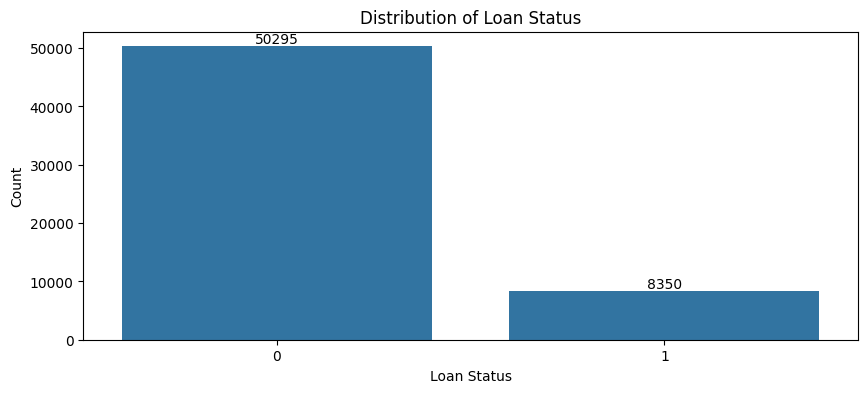

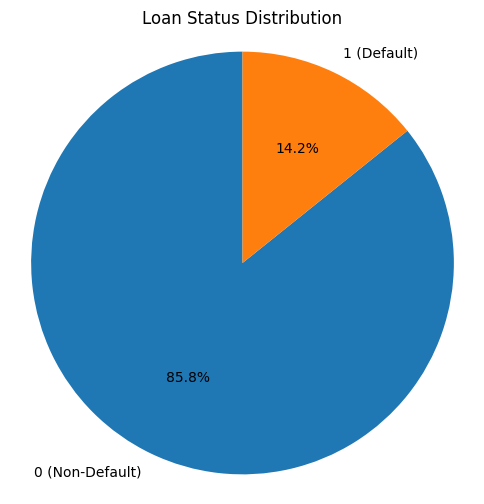

In [18]:
plt.figure(figsize=(10,4))
ax = sns.countplot(x=df["loan_status"])
target_count = df['loan_status'].value_counts().sort_index()

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6,6))
plt.pie(
    target_count,
    labels=['0 (Non-Default)', '1 (Default)'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Loan Status Distribution')
plt.axis('equal')
plt.show()

Target Variable Analysis (loan_status)

• The target variable is binary, containing only two classes:
    - 0 : Non-default / Loan approved successfully
    - 1 : Default / Risky borrower

• There are no missing values in the target variable.

• Since the target variable is categorical and binary, there is no concept of outliers in the target variable.

• The target distribution is imbalanced:
    - Class 0 constitutes approximately 85.8% of the observations.
    - Class 1 constitutes approximately 14.2% of the observations.

• Since this is a binary classification problem, classification algorithms should be used rather than regression algorithms.

• Transformation of the target variable (such as log, square root, or standardization) is not required because 
   the target variable is already encoded as binary classes (0 and 1).

• Due to the class imbalance, model evaluation should not rely solely on accuracy.
  Metrics such as Precision, Recall, F1-score, ROC-AUC, and the confusion matrix should be considered.

• Tree-based ensemble models such as XGBoost are well-suited for this problem because they handle 
   nonlinear relationships, feature interactions, and moderate class imbalance effectively.

Conclusion:
The problem is a binary classification task with a moderately imbalanced target variable. 
No preprocessing or transformation of the target variable is required. 
A tree-based classification model such as XGBoost is an appropriate choice for this loan approval prediction problem.

# TRAIN TEST SPLIT

In [19]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# Detailed EDA on Train Data only

In [21]:
print(X_train.shape)
print(X_test.shape)

(46916, 11)
(11729, 11)


In [22]:
X_train.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,46916.000000,4.691600e+04,46916.000000,46916.000000,46916.000000,46916.000000,46916.000000
mean,27.554928,6.412984e+04,4.709950,9200.711953,10.682280,0.158849,5.819891
std,6.041646,3.856284e+04,3.982481,5562.186331,3.037979,0.091608,4.035873
min,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000
25%,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000
50%,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000
75%,30.000000,7.581000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000
max,123.000000,1.900000e+06,123.000000,35000.000000,23.060000,0.830000,30.000000


1. person_age:
  Minimum age = 20 years
  Maximum age = 123 years

  The maximum age of 123 years appears unrealistic and suggests the presence of outliers or data quality issues.

  25% of borrowers are ≤ 23 years old.
  50% of borrowers are ≤ 26 years old.
  75% of borrowers are ≤ 30 years old.
  This indicates that most borrowers are relatively young.

2. Mean   = 27.55
   Median = 26
   Mean > Median
   the age distribution is positively (right) skewed, likely due to a few unusually old borrowers.

3. Std = 6.04
   This means borrower ages are not highly dispersed; most borrowers fall within a relatively narrow age range.
   A rough interpretation: 27.55 ± 6.04
   gives: 21.5 to 33.6 years
   which contains a large proportion of borrowers.


4. Conclusion
   The person_age variable has a median age of 26 years and an average age of 27.55 years,
   indicating a slightly positively skewed distribution.
   Most borrowers are young adults, typically between 22 and 34 years old.
   The presence of very high ages creates a long right tail and suggests potential outliers.

1. person_income:
   Minimum income = 4,200
   Maximum income = 1,900,000

   There is an extremely large range of incomes.

   25% of borrowers earn ≤ 42,000.
   50% of borrowers earn ≤ 58,000.
   75% of borrowers earn ≤ 75,810.
   The remaining 25% are not all at 1,900,000.
   They are spread somewhere between 75,810 and 1,900,000.

   Most borrowers have relatively moderate incomes.


2. Mean vs Median
   Mean   = 64,130
   Median = 58,000

   Since: Mean > Median
   the income distribution is positively skewed.
   A small number of very high-income borrowers increase the average substantially.

4. Standard Deviation
   Std = 38,563
  This indicates substantial variation in borrower income. 
  A rough interpretation: 64130 ± 38563
  gives: 25567 to 102693


5. Conclusion
   The person_income variable exhibits a strongly positively skewed distribution.
   While most borrowers have moderate incomes, a relatively small number of borrowers
   have extremely high incomes, producing a long right tail.
   The large standard deviation indicates considerable variability in income levels.

1. person_emp_length:
   Minimum employment length = 0 years
   Maximum employment length = 123 years
   The maximum value is unrealistic and suggests outliers.

   25% of borrowers have employment length ≤ 2 years.
   50% of borrowers have employment length ≤ 4 years.
   75% of borrowers have employment length ≤ 7 years.

   Most borrowers have relatively short employment histories.

2. Mean vs Median
   Mean   = 4.71
   Median = 4
   Since:Mean > Median
   the distribution is positively skewed.

3. Standard Deviation
   Std = 3.98
   Employment duration varies moderately across borrowers.
   A rough interpretation: 4.7 ± 4
   gives: 1 to 9 years

  The person_emp_length variable is positively skewed due to a small number of
  borrowers with extremely long employment histories.
  Most borrowers have between 1 and 9 years of employment experience.


loan_amnt:

75% of borrowers borrow ≤ 12,000
but some borrowers borrow up to 35,000.
This indicates a long tail toward larger loan amounts.
"75 percent of the people are equal or below 12000."
The remaining 25% are not all at 35,000.
They are spread somewhere between 12,000 and 35,000.

Mean vs Median
Mean   = 9200
Median = 8000
Why is the mean larger than the median?
this tellls us - The distribution is positively (right) skewed.


std -it tells - On average, how far the loan amounts are spread out from the mean.

Mean = 9200
Std  = 5562
it means:Loan amounts vary a lot. Borrowers do not all borrow around ₹9200; 
        many borrow substantially less or substantially more

A rough interpretation is: 9200 ± 5562
which gives: 3638 to 14762
This means that a large portion of borrowers borrow somewhere around this range.


conclusion:
loan_amnt has a median of $8,000 and an average of $9,200,
indicating a positively skewed distribution.
The standard deviation of approximately $5,562 suggests
substantial variability in loan sizes among borrowers.
Most borrowers take relatively small loans, while a smaller
number of borrowers take significantly larger loans,
creating a long right tail.

loan_int_rate:
Basic observations
Minimum interest rate = 5.42%
Maximum interest rate = 23.06%

Interest rates span a wide range.

25% of borrowers have interest rates ≤ 7.88%.
50% have interest rates ≤ 10.75%.
75% have interest rates ≤ 12.99%.

Mean vs Median
Mean   = 10.68
Median = 10.75

Since: Mean ≈ Median
the distribution appears relatively symmetric.

Standard Deviation
Std = 3.04
This indicates moderate variability in interest rates.
A rough interpretation: 10.68 ± 3.04
gives: 7.64% to 13.72%

Conclusion
The loan_int_rate variable appears relatively symmetric,
with moderate variation in interest rates across borrowers.
Most loans have interest rates between approximately 8% and 14%.

loan_percent_income:
Minimum = 0
Maximum = 0.83

Some borrowers allocate a very high proportion of their income to loan repayment.

25% of borrowers allocate ≤ 9% of income.
50% allocate ≤ 14% of income.
75% allocate ≤ 21% of income.
    
Mean vs Median
Mean   = 0.159
Median = 0.140
Since: Mean > Median

the distribution is positively skewed.

Standard Deviation
Std = 0.092
There is moderate variability in debt burden among borrowers.

Conclusion
The loan_percent_income variable is positively skewed.
Most borrowers allocate a relatively small proportion of their income
toward loan repayment, while a minority of borrowers allocate substantially more.

cb_person_cred_hist_length:
Minimum credit history length = 2 years
Maximum credit history length = 30 years
25% of borrowers have credit histories ≤ 3 years.
50% have credit histories ≤ 4 years.
75% have credit histories ≤ 8 years.

Most borrowers have relatively short credit histories.

Mean vs Median
Mean   = 5.82
Median = 4

Since: Mean > Median
the distribution is positively skewed.

Standard Deviation
Std = 4.04
This indicates considerable variation in credit history length.
A rough interpretation: 5.8 ± 4
gives: 2 to 10 years

Conclusion
The cb_person_cred_hist_length variable is positively skewed.
Most borrowers have relatively short credit histories,
while a smaller number have substantially longer credit records,
creating a long right tail.

In [23]:
X_train.describe(include="object")

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,46916,46916,46916,46916
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,24475,9794,16769,39900


1. person_home_ownership

Number of unique categories = 4
Most frequent category = RENT
Frequency of RENT = 24,475

This means: There are four types of home ownership among borrowers.
The most common category is: RENT
with: 24,475 borrowers
Percentage of the dominant category
24,475 / 46,916 ≈ 52.2%.

This means: Approximately 52% of borrowers live in rented homes.
Interpretation

This suggests that:

Renting is the dominant housing status.
Home ownership is not evenly distributed.
Housing status may carry important information regarding creditworthiness and financial stability.

Conclusion
The person_home_ownership variable contains four categories,
with RENT being the most common category, representing approximately
52% of borrowers. This indicates that a majority of borrowers do not
own their homes, suggesting that home ownership status may be an
important predictor of loan approval or default risk.

loan_intent:
Number of unique categories = 6
Most frequent category = EDUCATION
Frequency  = 9794

This means: There are six different purposes for taking a loan.
The most common purpose is: EDUCATION
with: 9794 borrowers
Percentage of the dominant category
9794 / 46,916 ≈ ≈ 20.9%.

This means: About 21% of borrowers took loans for educational purposes.

Interpretation:
Since the largest category accounts for only around 21%:
loan_intent appears relatively balanced.
This is beneficial because:
No single loan purpose dominates the dataset.
Different loan purposes may have different default risks.

Conclusion
The loan_intent variable contains six categories,
with EDUCATION being the most common loan purpose,
representing approximately 21% of borrowers.
The distribution appears relatively balanced,
suggesting that loan purpose is likely to be an
informative feature for predicting loan outcomes.

3. loan_grade
Number of unique categories = 7
Most frequent category = A
Frequency = 16,769

This means: Loans are classified into seven grades, from A to G.
The most frequent grade is: Grade A

Percentage of the dominant category
16,769 / 46,916 ≈ 35.7%

This means: Approximately 36% of all loans belong to the highest credit grade.

Interpretation
This suggests:
The dataset contains a substantial proportion of high-quality borrowers.
Loan grade is likely one of the strongest predictors of loan approval/default.


loan_grade to have high feature importance.
    
Conclusion
The loan_grade variable contains seven ordered categories,
with Grade A loans representing approximately 36% of all loans.
The distribution indicates that the dataset contains a large
proportion of high-quality borrowers, making loan grade a
potentially strong predictor of loan performance.

cb_person_default_on_file

Number of unique categories = 2
Most frequent category = N
Frequency = 39,900

This means: Borrowers either have or do not have a previous default record.

The majority category is:

N (No previous default)
Percentage of the dominant category
39,900 / 46,916 ≈ 85.0%

This means: Approximately 85% of borrowers have no previous default history.

Interpretation

This indicates a highly imbalanced categorical feature.

However, from a business perspective:

Previous default history is expected to be a strong predictor
of future loan default risk.

Conclusion
The cb_person_default_on_file variable is a binary categorical feature,
with approximately 85% of borrowers having no prior default history.
Although the distribution is imbalanced, previous default status is
expected to be a highly informative predictor of loan repayment behavior.

Overall observation: 
• person_home_ownership is moderately imbalanced.
• loan_intent is relatively balanced.
• loan_grade is ordinal and likely highly predictive.
• cb_person_default_on_file is strongly imbalanced but business-critical.

Among these categorical features, loan_grade and
cb_person_default_on_file are expected to have the
highest predictive power for loan approval/default prediction.

In [24]:
 X_train.duplicated().sum()

np.int64(0)

In [25]:
# No missing values were observed in the dataset; therefore, no imputation techniques were required.

In [26]:
X_train.nunique().sort_values()

cb_person_default_on_file        2
person_home_ownership            4
loan_intent                      6
loan_grade                       7
cb_person_cred_hist_length      29
person_emp_length               36
person_age                      52
loan_percent_income             59
loan_int_rate                  353
loan_amnt                      516
person_income                 2373
dtype: int64

### Univariate Analysis (Each Feature Alone)

In [27]:
# The purpose is to understand:

# Distribution shape
# Skewness
# Outliers
# Range of values
# Dominant categories
# Whether transformation is needed

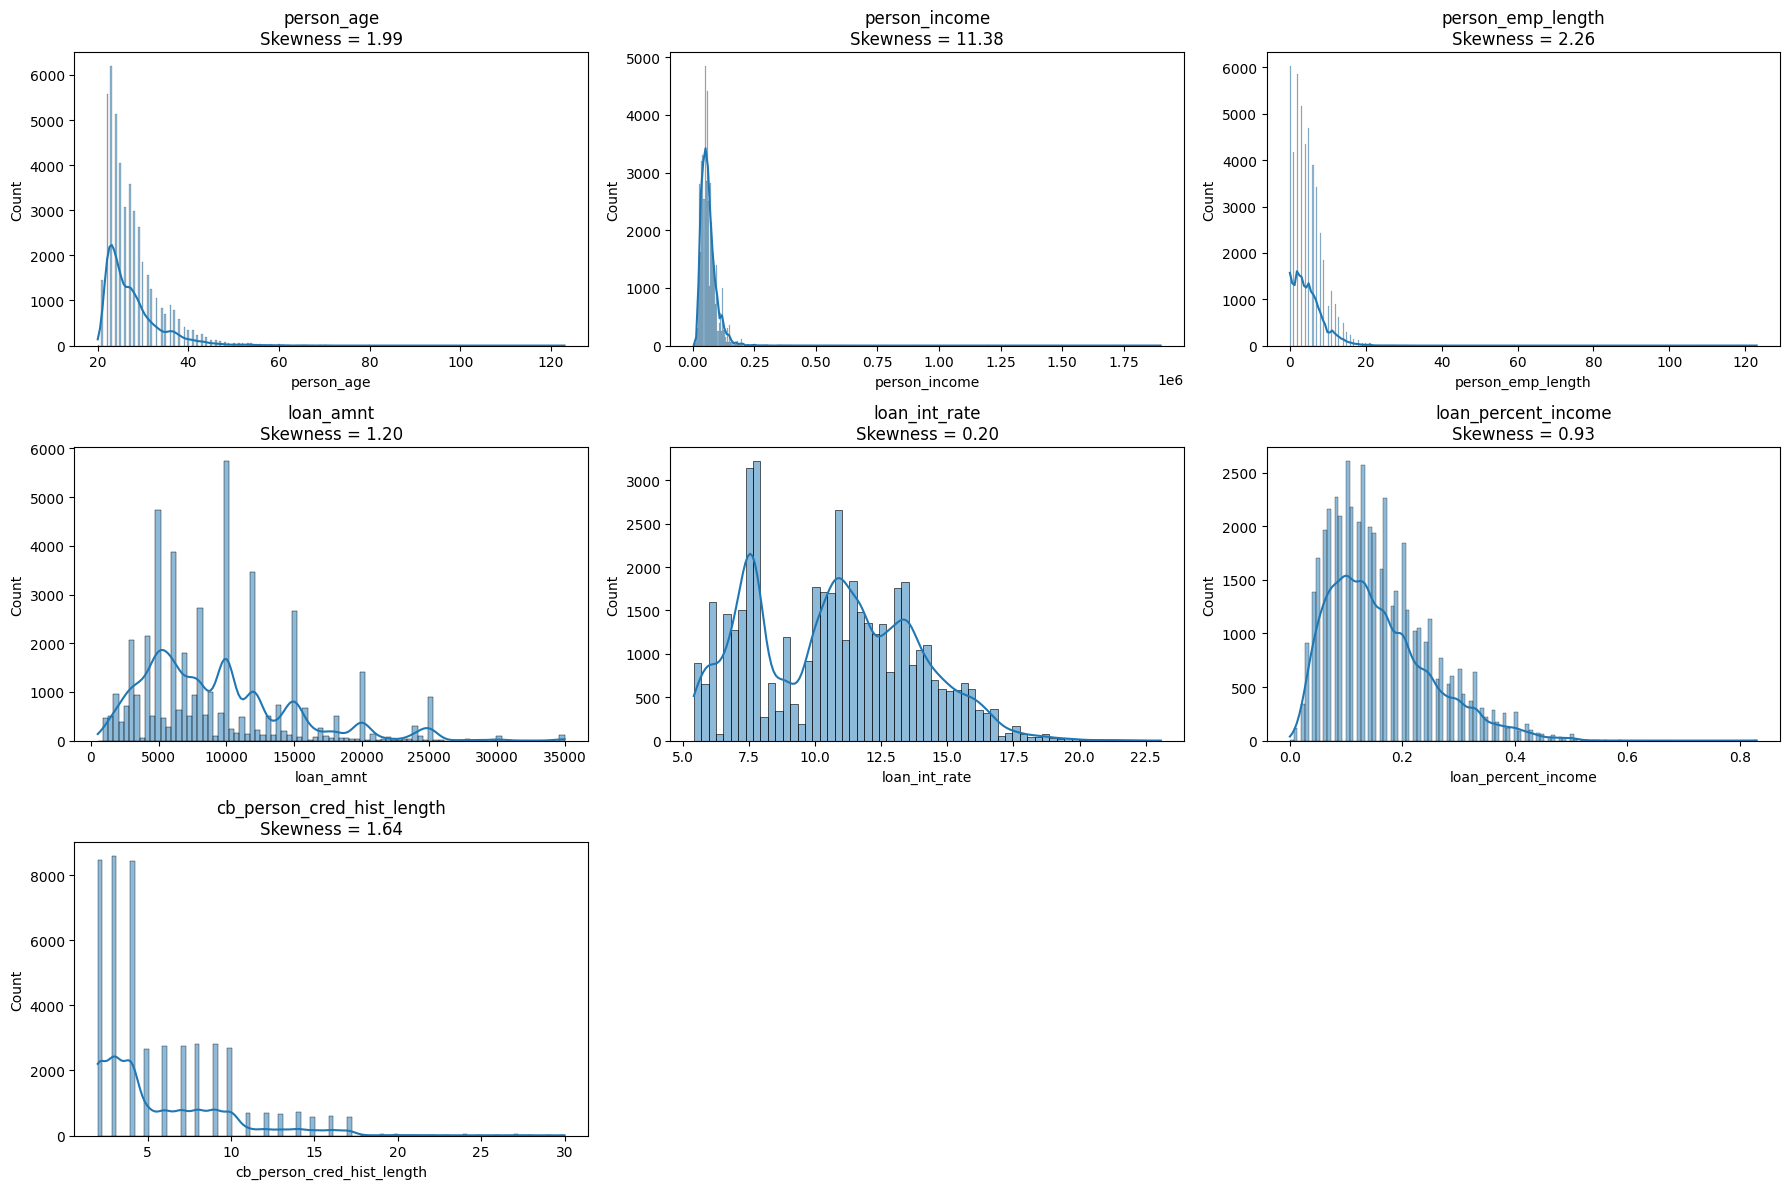

In [28]:
num_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)

    sns.histplot(X_train[col], kde=True)

    plt.title(
        f"{col}\nSkewness = {X_train[col].skew():.2f}"
    )

plt.tight_layout()
plt.savefig('num_feature_skewness.png')
plt.show()

person_income has highest skewness 11.38

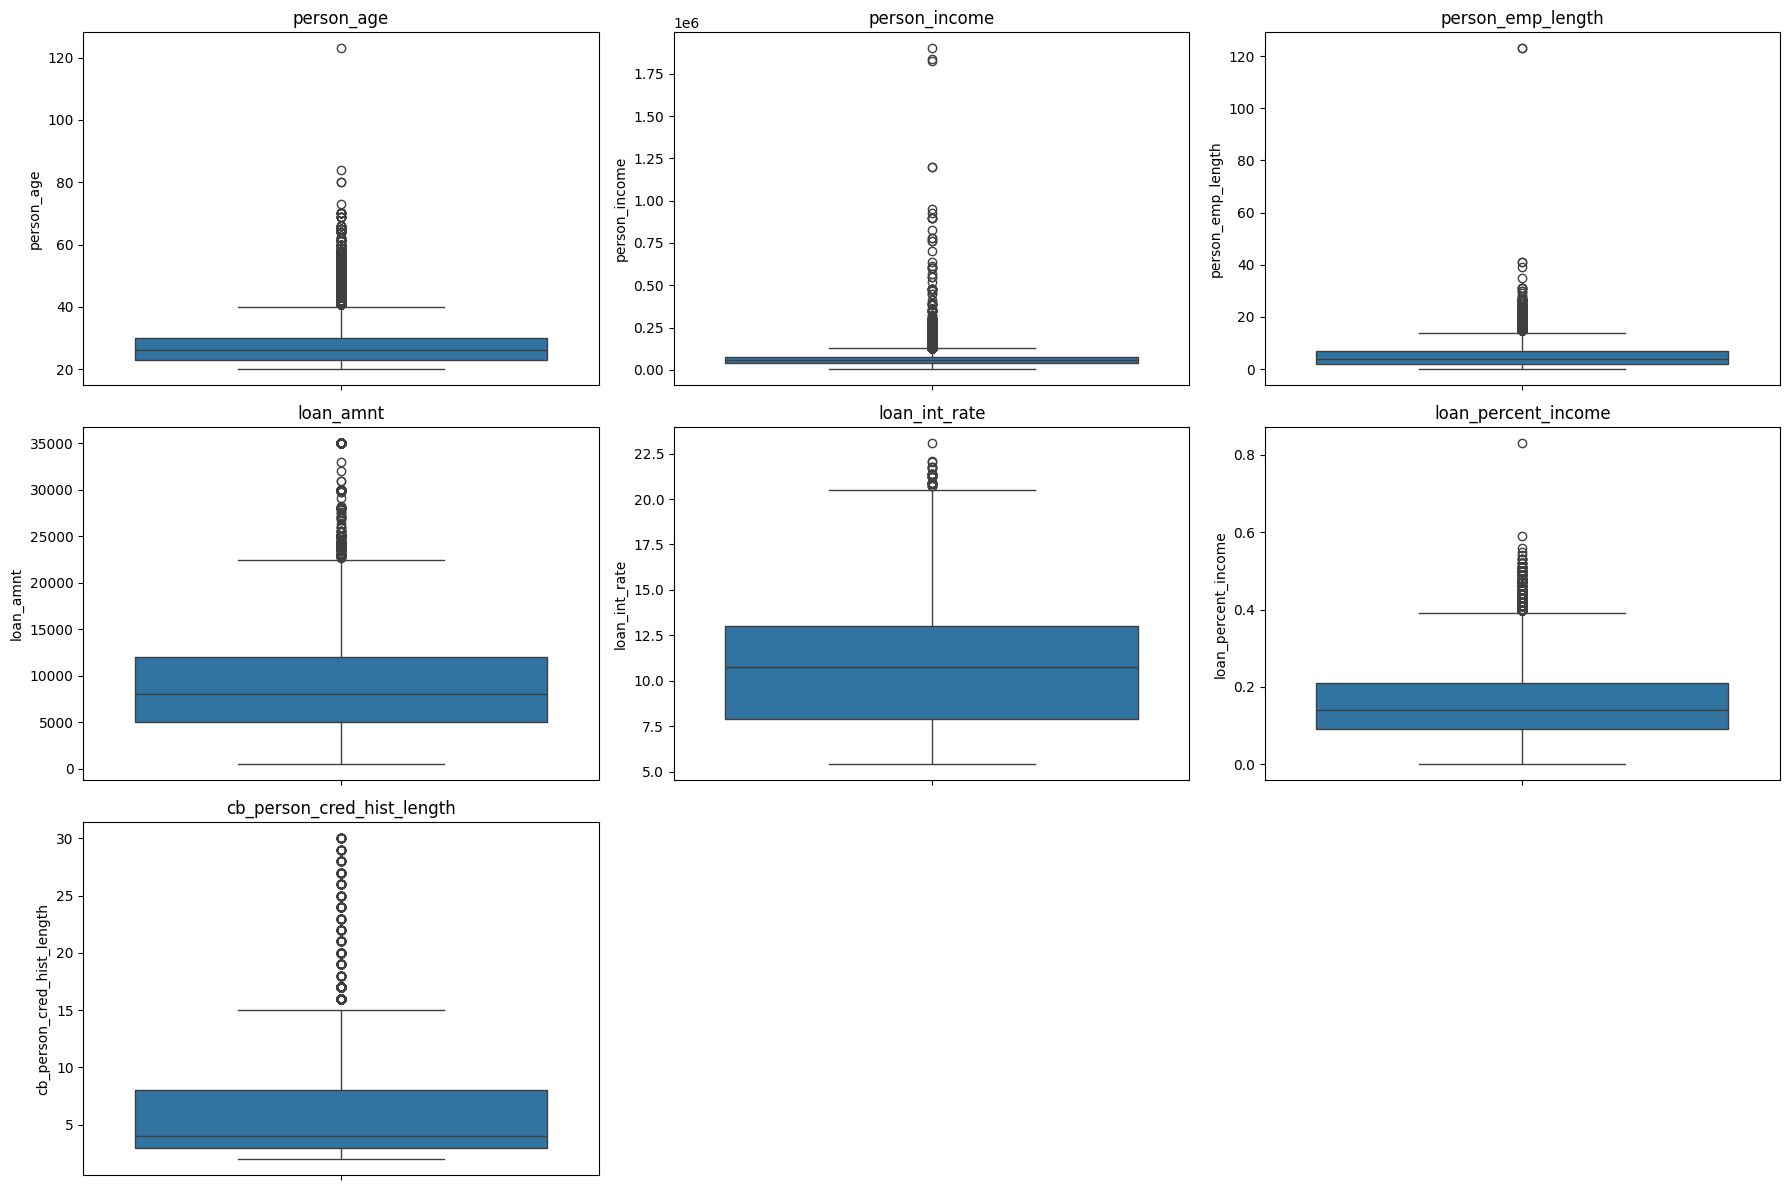

In [29]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)

    sns.boxplot(y=X_train[col])

    plt.title(col)

plt.tight_layout()
plt.savefig('num_feature_boxplots.png')
plt.show()

 1. The distribution normal is not normal . 
 2. Every feature is  right-skewed . 
 3. Every Feature has outliers?
 4. It needs transformation?

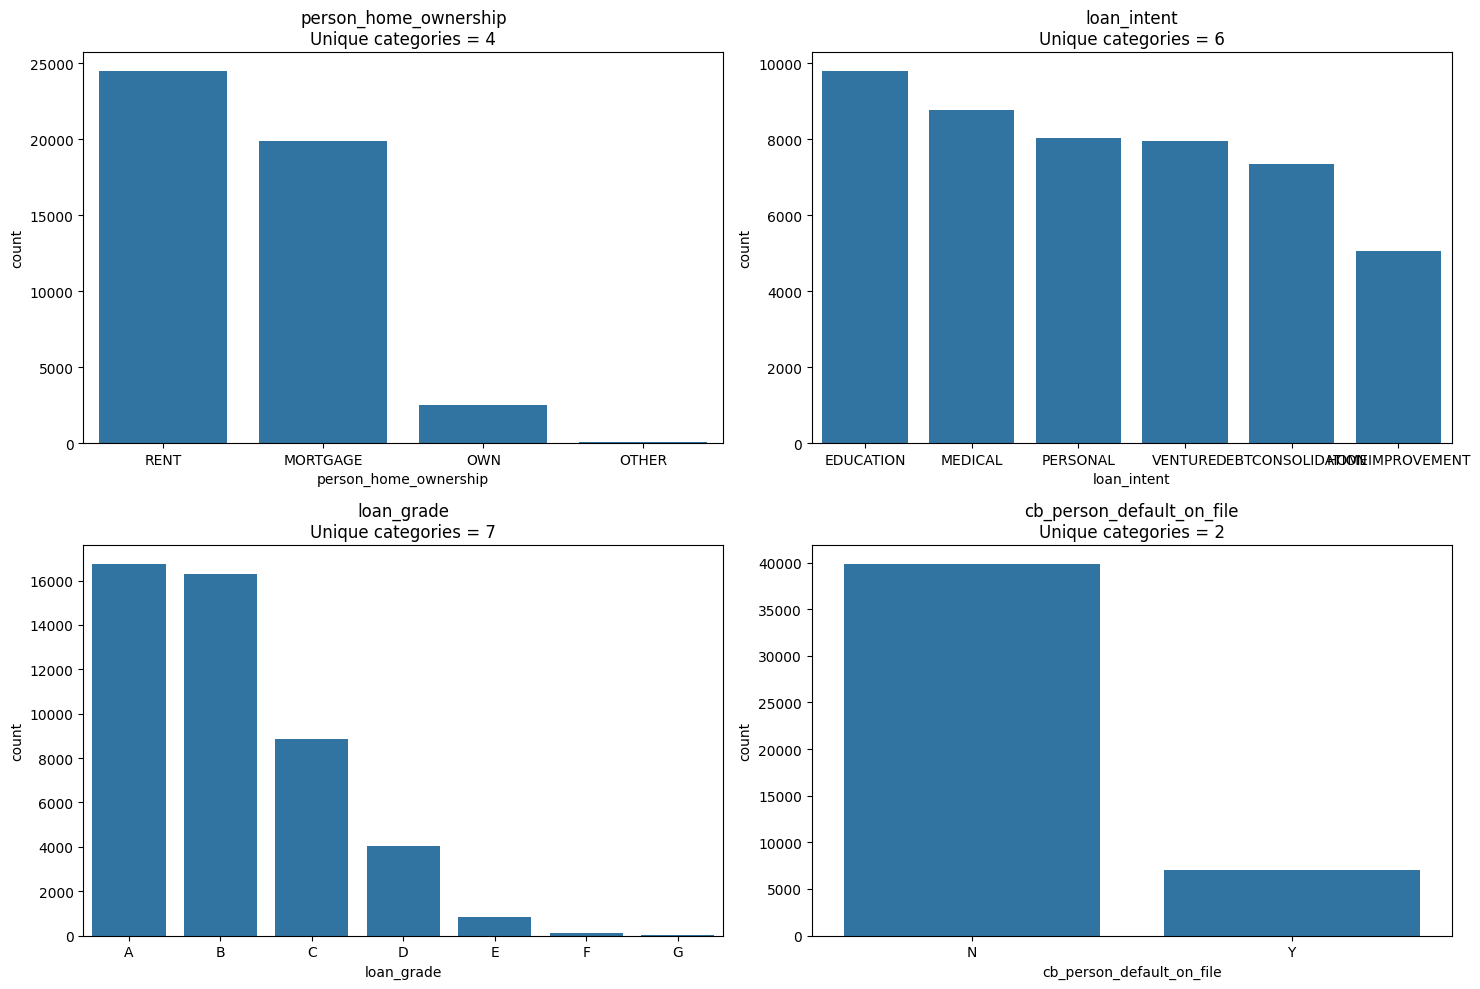

In [30]:
cat_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)

    order = X_train[col].value_counts().index

    sns.countplot(
        x=X_train[col],
        order=order
    )

    plt.title(
        f"{col}\nUnique categories = {X_train[col].nunique()}"
    )

plt.tight_layout()
plt.savefig('categorical_feature.png')
plt.show()

1. RENT , EDUCATION , A , and NO categories are dominant . 
2. loan intent and loan grade are imbalanced . And home ownership and default history are highly imbalanced.
3.  all feaures are highly informative . 

### Bivariate Analysis

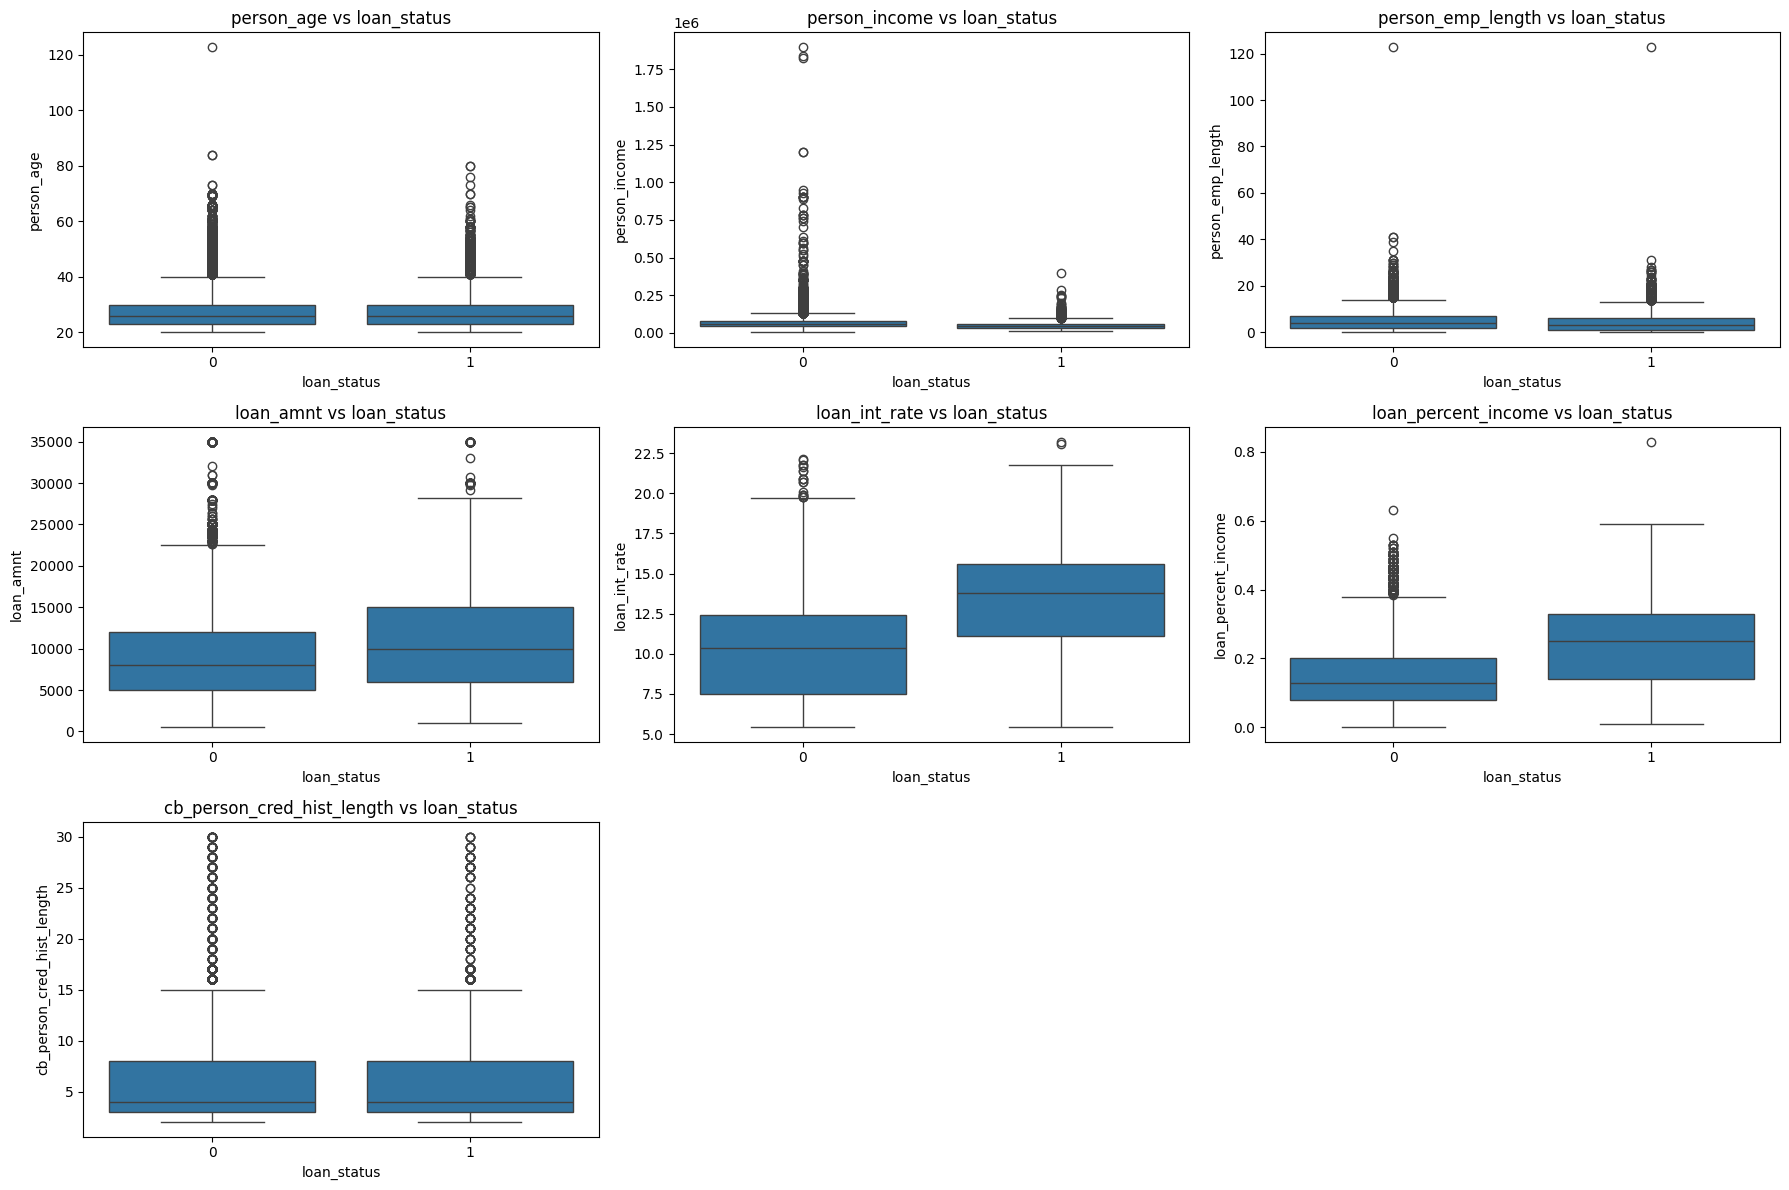

In [31]:
# Numerical Features vs loan_status
plt.figure(figsize=(18, 12))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)

    sns.boxplot(
        x='loan_status',
        y=col,
        data=df
    )

    plt.title(f'{col} vs loan_status')

plt.tight_layout()
plt.show()

1. Feature like loan_int_rate and loan_percent_income show a clear vertical shift in their medians between 
     the two loan statuses.    
     feature like person age and cb_person_cred_hist_length. 
2. THe spread of data can be evaluated by the height of the boxes (IQR) and the length of the whiskers.
     person_income has a very large overall range with upper whiskers, reflecting high dispersion in applicant income.
3. outliers are present almost in every features.  

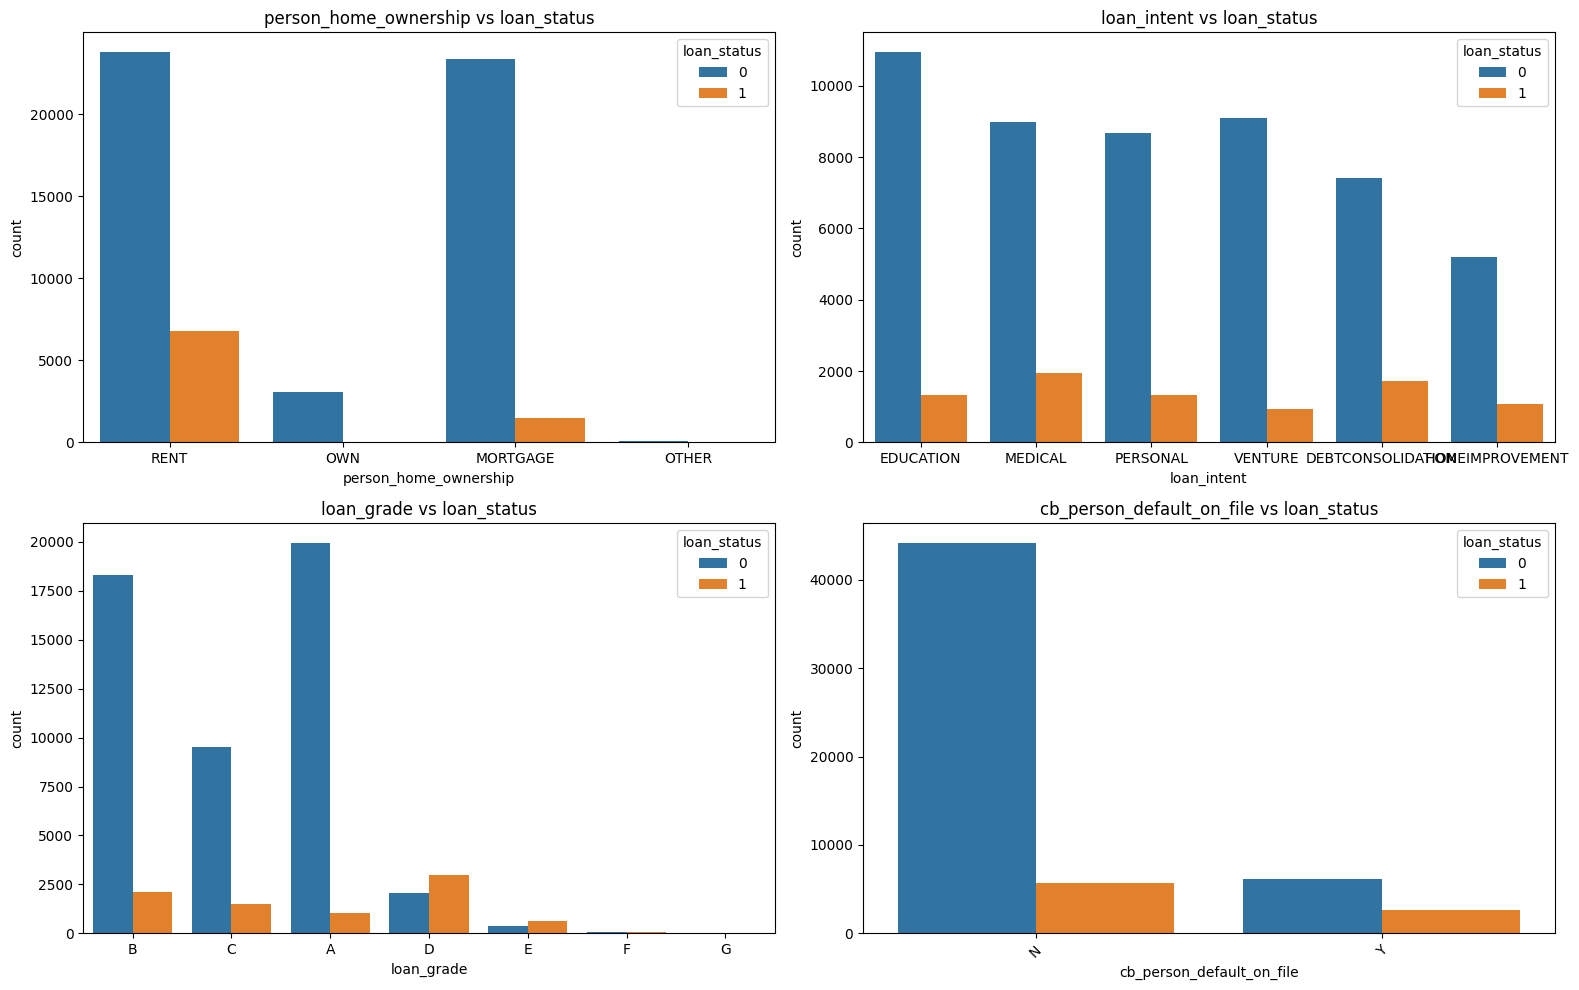

In [32]:
# Categorical feature vs loan_status
plt.figure(figsize=(16, 10))

for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)

    sns.countplot(
        x=col,
        hue='loan_status',
        data=df
    )

    plt.title(f'{col} vs loan_status')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

1. in loan_intent vs loan_status , the medical and debt consolidation categories appear to have higher counts of defaults.
     Education and medical shows higher frequency.
2. categories has fewer defaults - The Venture and Home Improvements. 
3. Is this feature likely to be important - Yes loan grade(strongest predictor) , loan intent

### Multivariate Analysis

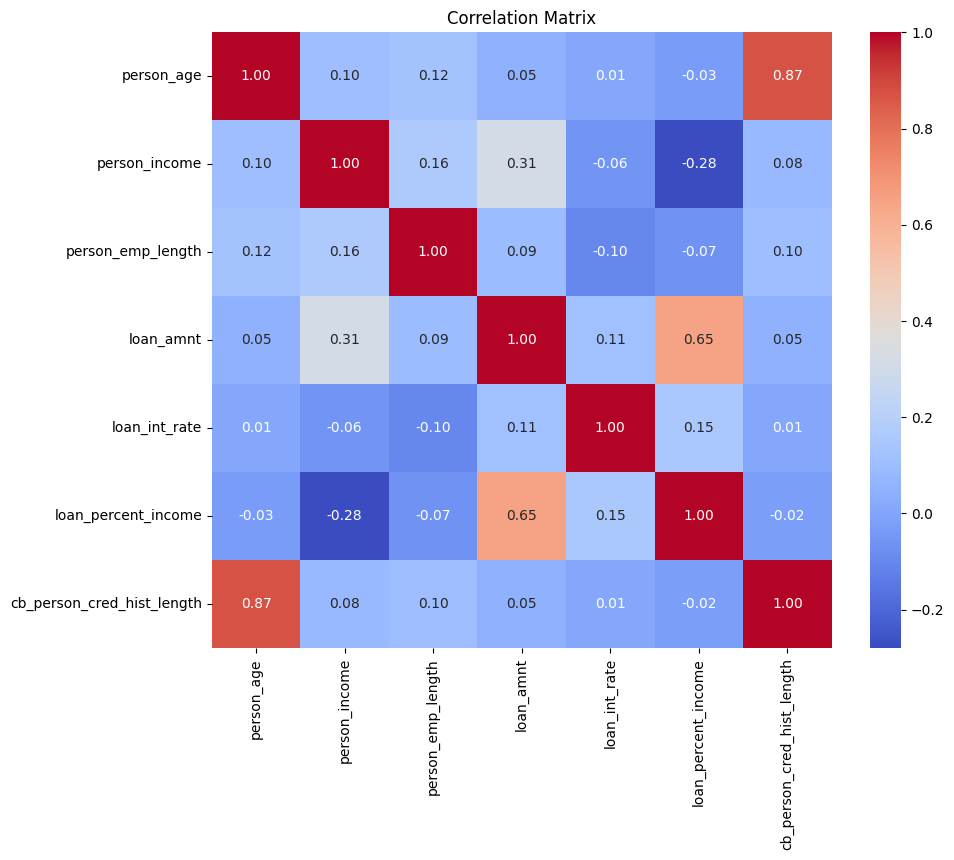

In [33]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

1. THe strongest relationship exists bw Person_age and cb_person_cred_hist_hist_lenght (0.87).  
2. This suggests that borrowers with higher ages 
   generally have longer credit histories, which is expected from a business
   perspective.

### Outliers Analysis

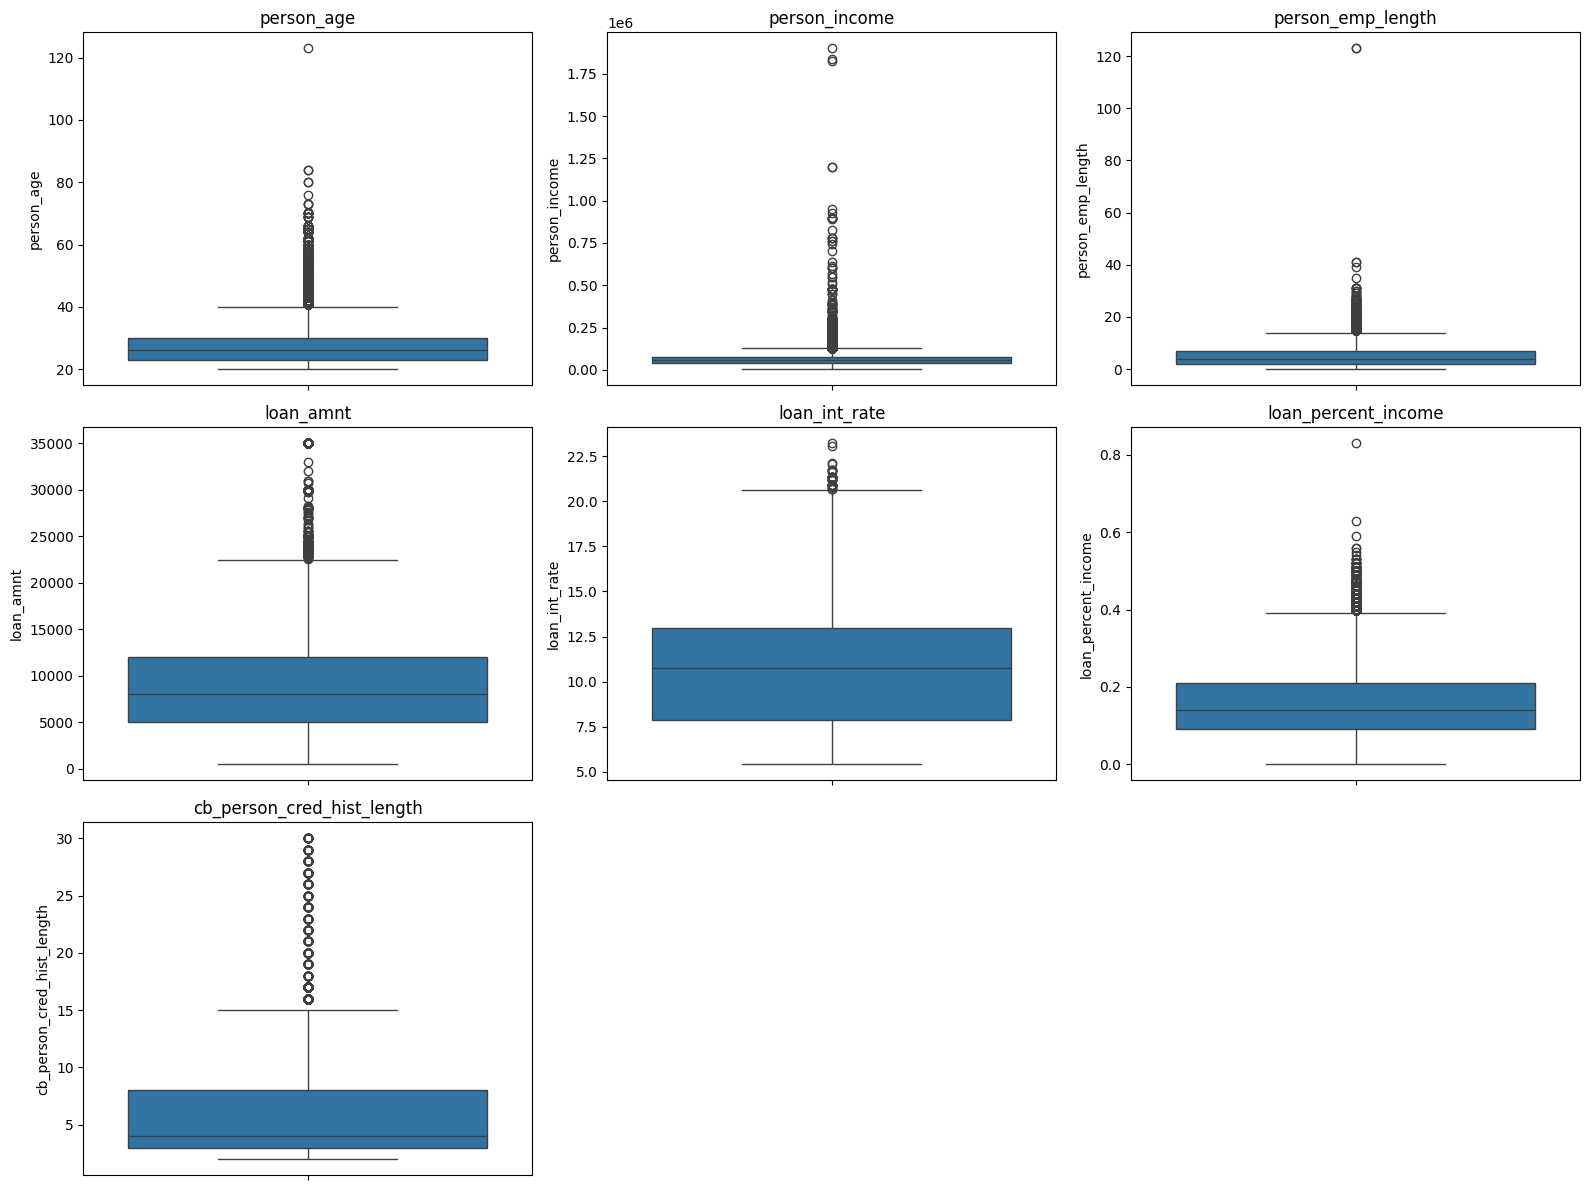

In [34]:
cols = 3
rows = (len(num_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# Hide empty plots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [35]:
def outlier_report(df, cols):

    report = []

    for col in cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = (
            (df[col] < lower) |
            (df[col] > upper)
        )

        report.append({
            'Column': col,
            'Lower Bound': round(lower,2),
            'Upper Bound': round(upper,2),
            'Outlier Count': outliers.sum(),
            'Outlier %': round(
                outliers.mean()*100,2
            )
        })

    return pd.DataFrame(report).sort_values(
        'Outlier %',
        ascending=False
    )

outlier_df = outlier_report(df, num_cols)

print(outlier_df)

                       Column  Lower Bound  Upper Bound  Outlier Count  \
0                  person_age        12.50        40.50           2446   
1               person_income     -8400.00    126000.00           2411   
3                   loan_amnt     -5500.00     22500.00           2045   
6  cb_person_cred_hist_length        -4.50        15.50           1993   
2           person_emp_length        -5.50        14.50           1274   
5         loan_percent_income        -0.09         0.39           1210   
4               loan_int_rate         0.21        20.66             34   

   Outlier %  
0       4.17  
1       4.11  
3       3.49  
6       3.40  
2       2.17  
5       2.06  
4       0.06  


In [36]:
skew_df = (
    df[num_cols]
    .skew()
    .sort_values(ascending=False)
)

print(skew_df)

person_income                 10.457723
person_emp_length              2.054430
person_age                     1.965497
cb_person_cred_hist_length     1.618503
loan_amnt                      1.188578
loan_percent_income            0.917473
loan_int_rate                  0.200020
dtype: float64


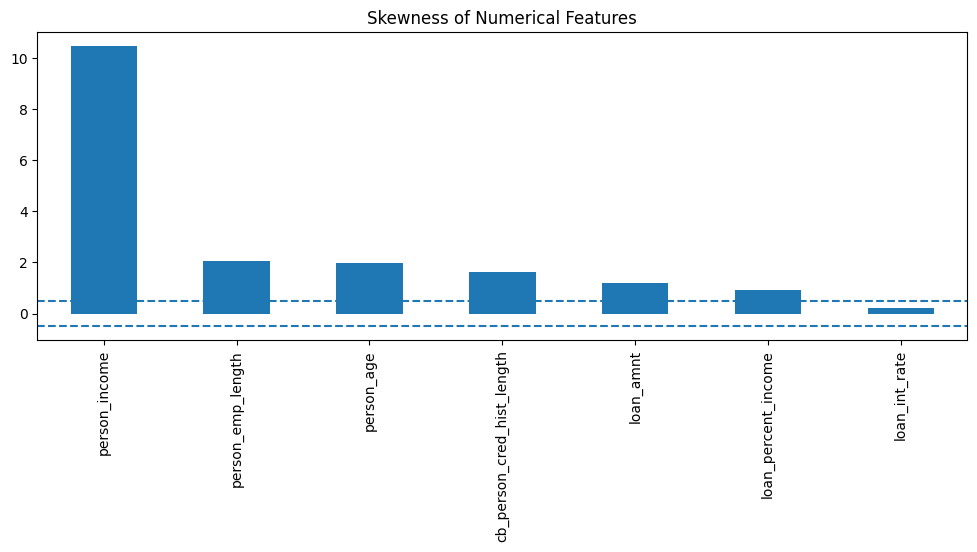

In [37]:
plt.figure(figsize=(12,4))

skew_df.plot(kind='bar')

plt.axhline(
    y=0.5,
    linestyle='--'
)

plt.axhline(
    y=-0.5,
    linestyle='--'
)

plt.title('Skewness of Numerical Features')

plt.show()

In [38]:
def check_transformations(series, name):

    print(f'\n{name}')
    print(
        'Original :',
        round(series.skew(),3)
    )

    if series.min() >= 0:
        print(
            'sqrt     :',
            round(
                np.sqrt(series).skew(),
                3
            )
        )

        print(
            'log1p    :',
            round(
                np.log1p(series).skew(),
                3
            )
        )

    print(
        'cbrt     :',
        round(
            np.cbrt(series).skew(),
            3
        )
    )


for col in num_cols:

    if abs(X_train[col].skew()) > 0.5:
        check_transformations(
            X_train[col],
            col
        )


person_age
Original : 1.99
sqrt     : 1.531
log1p    : 1.206
cbrt     : 1.407

person_income
Original : 11.382
sqrt     : 1.86
log1p    : 0.223
cbrt     : 1.072

person_emp_length
Original : 2.26
sqrt     : -0.218
log1p    : -0.48
cbrt     : -0.959

loan_amnt
Original : 1.196
sqrt     : 0.405
log1p    : -0.456
cbrt     : 0.133

loan_percent_income
Original : 0.926
sqrt     : 0.25
log1p    : 0.732
cbrt     : 0.001

cb_person_cred_hist_length
Original : 1.641
sqrt     : 0.877
log1p    : 0.471
cbrt     : 0.673


Professional Decision Rule

Use this rule exactly:

|Skewness| < 0.5     → Keep as is
0.5–1.0              → Moderate skew
> 1.0                → Strong skew, consider transformation

For outliers:

If outliers are data-entry errors
    → Remove them

If outliers are valid business observations
    → Keep them or winsorize them

For tree models (XGBoost/LightGBM)
    → Usually keep valid outliers


Conclusion: For outliers
for 
  1. person_age  - I will try different methods(ex - z_score, IQR...)and then decide
  2. person_income - log1p
  3.  person_emp_length - I will different methods. 
  4.  loan_amnt - I will different methods
  5. loan_percent_income - I will different methods
  6.  cb_person_cred_hist_length - log1p

### Categorical Feature Analysis

In [39]:
X_train['person_home_ownership'].value_counts(dropna=False)

person_home_ownership
RENT        24475
MORTGAGE    19857
OWN          2515
OTHER          69
Name: count, dtype: int64

Feature Type       : Nominal Categorical
Unique Categories  : 4

Decision:
The categories in person_home_ownership do not possess any natural ordering.
Therefore, One-Hot Encoding will be applied to convert the categories into
binary indicator variables while avoiding introducing artificial relationships
between categories.

Encoding Method:
One-Hot Encoding (drop_first=True)

In [40]:
X_train['loan_intent'].value_counts(dropna=False)

loan_intent
EDUCATION            9794
MEDICAL              8755
PERSONAL             8024
VENTURE              7945
DEBTCONSOLIDATION    7340
HOMEIMPROVEMENT      5058
Name: count, dtype: int64

Feature Type       : Nominal Categorical
Unique Categories  : 6

Decision:
The categories in loan_intent represent different loan purposes and do not
have an inherent ranking. Therefore, One-Hot Encoding will be used to preserve
all category information without imposing an ordinal relationship.

Encoding Method:
One-Hot Encoding (drop_first=True)

In [41]:
X_train['loan_grade'].value_counts(dropna=False)

loan_grade
A    16769
B    16293
C     8859
D     4019
E      827
F      123
G       26
Name: count, dtype: int64

Feature Type       : Ordinal Categorical
Unique Categories  : 7

Decision:
The loan_grade feature has a natural ordering from A (highest credit quality)
to G (lowest credit quality). Therefore, Ordinal Encoding will be applied to
preserve the ranking information contained in the feature.

Encoding Method:
Ordinal Mapping

A → 1
B → 2
C → 3
D → 4
E → 5
F → 6
G → 7

In [42]:
X_train['cb_person_default_on_file'].value_counts(dropna=False)

cb_person_default_on_file
N    39900
Y     7016
Name: count, dtype: int64

Feature Type       : Binary Categorical
Unique Categories  : 2

Decision:
The feature contains only two categories (Y/N). Therefore, binary encoding
will be applied to convert the feature into numerical form while preserving
its meaning.

Encoding Method:
Binary Mapping

Y → 1
N → 0

# Biuld Preprocessing Pipeline

### Removing outliers

In [43]:
X_train_age = X_train.copy()

Q1 = X_train_age['person_age'].quantile(0.25)
Q3 = X_train_age['person_age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X_train_age = X_train_age[
    (X_train_age['person_age'] >= lower) &
    (X_train_age['person_age'] <= upper)
]


In [44]:
X_train_age['person_age'].skew()

np.float64(0.9991391406195866)

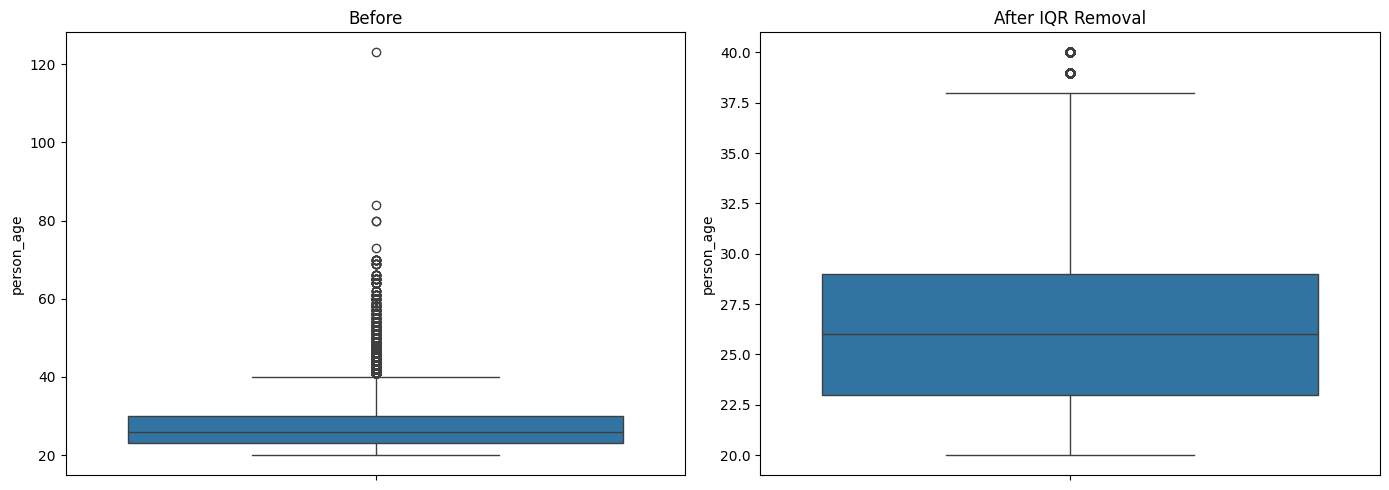

In [45]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(y=X_train['person_age'], ax=axes[0])
axes[0].set_title('Before')

sns.boxplot(y=X_train_age['person_age'], ax=axes[1])
axes[1].set_title('After IQR Removal')

plt.tight_layout()
plt.show()

In [46]:
X_train_income = X_train.copy()

X_train_income['person_income'] = np.log1p(
    X_train_income['person_income']
)

In [47]:
X_train_income['person_income'].skew()

np.float64(0.2228967419956449)

In [48]:
X_test['person_income'] = np.log1p(X_test['person_income'])

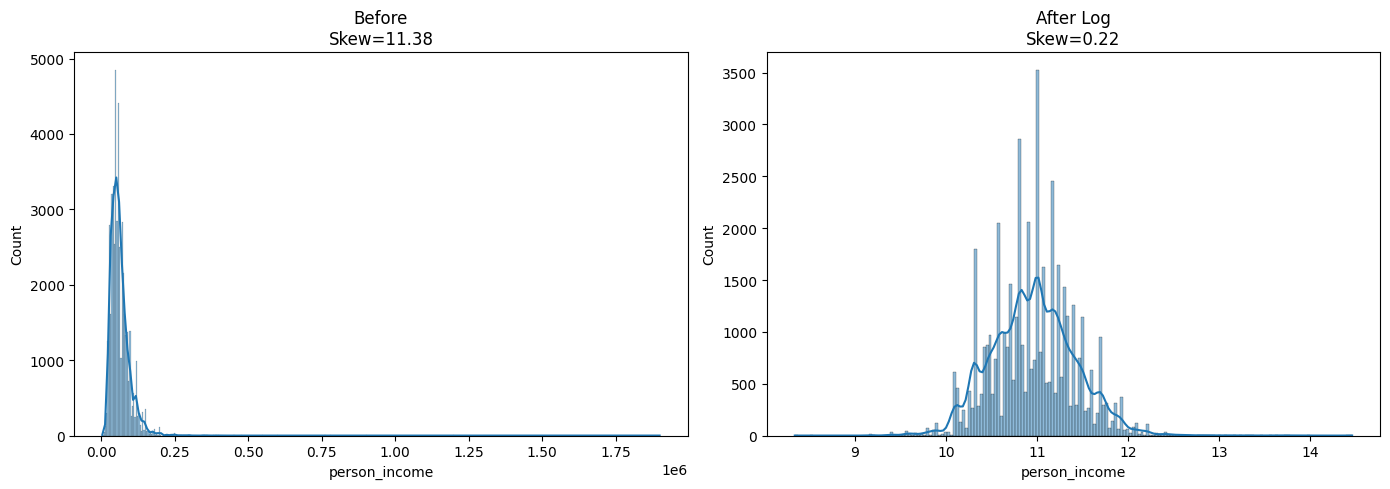

In [49]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(
    X_train['person_income'],
    kde=True,
    ax=axes[0]
)
axes[0].set_title(
    f'Before\nSkew={X_train["person_income"].skew():.2f}'
)

sns.histplot(
    X_train_income['person_income'],
    kde=True,
    ax=axes[1]
)
axes[1].set_title(
    f'After Log\nSkew={X_train_income["person_income"].skew():.2f}'
)

plt.tight_layout()
plt.show()

In [50]:
from scipy import stats

X_train_emp = X_train.copy()

z = np.abs(
    stats.zscore(
        X_train_emp['person_emp_length']
    )
)

X_train_emp = X_train_emp[
    z < 3
]


In [51]:
X_train_emp['person_emp_length'].skew()

np.float64(0.817589168595665)

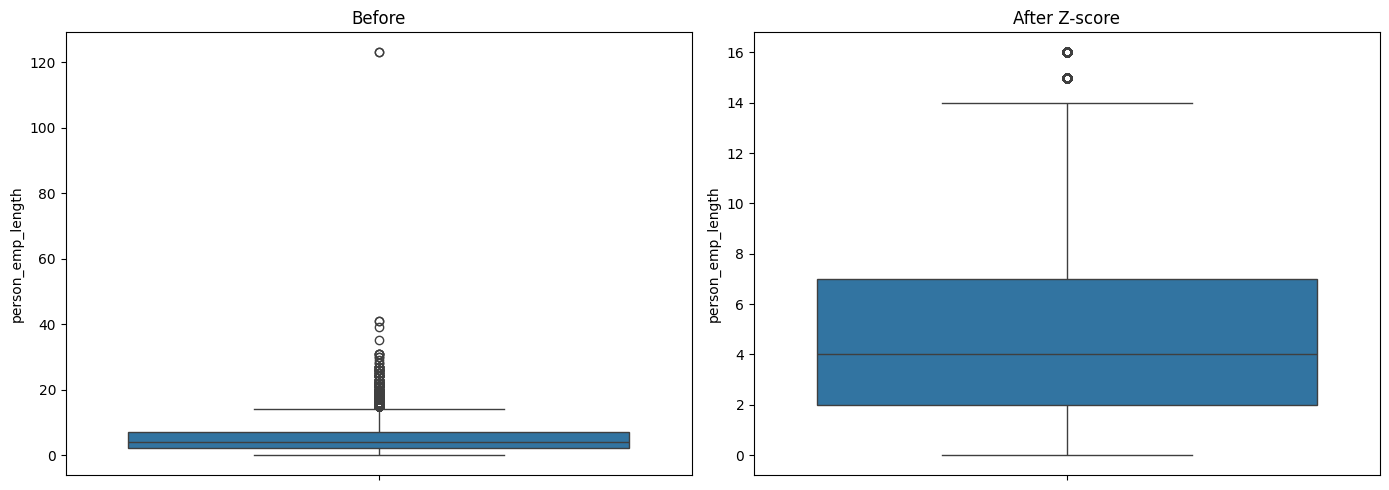

In [52]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(
    y=X_train['person_emp_length'],
    ax=axes[0]
)
axes[0].set_title('Before')

sns.boxplot(
    y=X_train_emp['person_emp_length'],
    ax=axes[1]
)
axes[1].set_title('After Z-score')

plt.tight_layout()
plt.show()

In [53]:
X_train_loan = X_train.copy()

Q1 = X_train_loan['loan_amnt'].quantile(0.25)
Q3 = X_train_loan['loan_amnt'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

X_train_loan = X_train_loan[
    (X_train_loan['loan_amnt'] >= lower) &
    (X_train_loan['loan_amnt'] <= upper)
]


In [54]:
X_train_loan['loan_amnt'].skew()

np.float64(0.677908486558992)

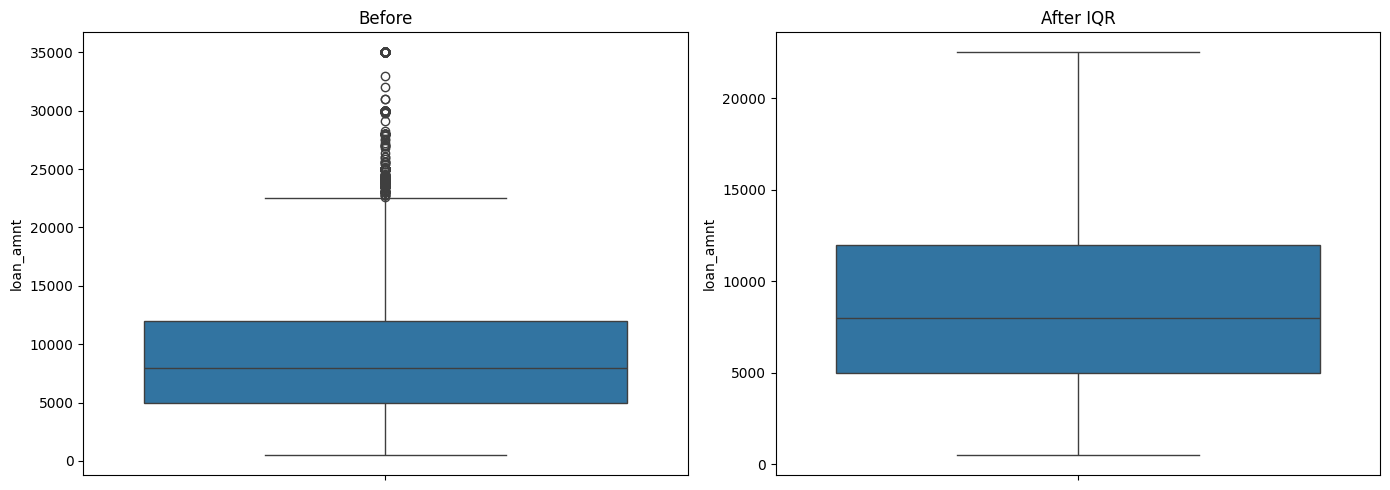

In [55]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(
    y=X_train['loan_amnt'],
    ax=axes[0]
)
axes[0].set_title('Before')

sns.boxplot(
    y=X_train_loan['loan_amnt'],
    ax=axes[1]
)
axes[1].set_title('After IQR')

plt.tight_layout()
plt.show()

In [56]:
X_train_pct = X_train.copy()

X_train_pct['loan_percent_income'] = np.sqrt(
    X_train_pct['loan_percent_income']
)


In [57]:
X_train_pct['loan_percent_income'].skew()

np.float64(0.24995331754765346)

In [58]:
X_test['loan_percent_income'] = np.sqrt(X_test['loan_percent_income'])

In [59]:
X_test['loan_percent_income'].skew()

np.float64(0.22717898214245116)

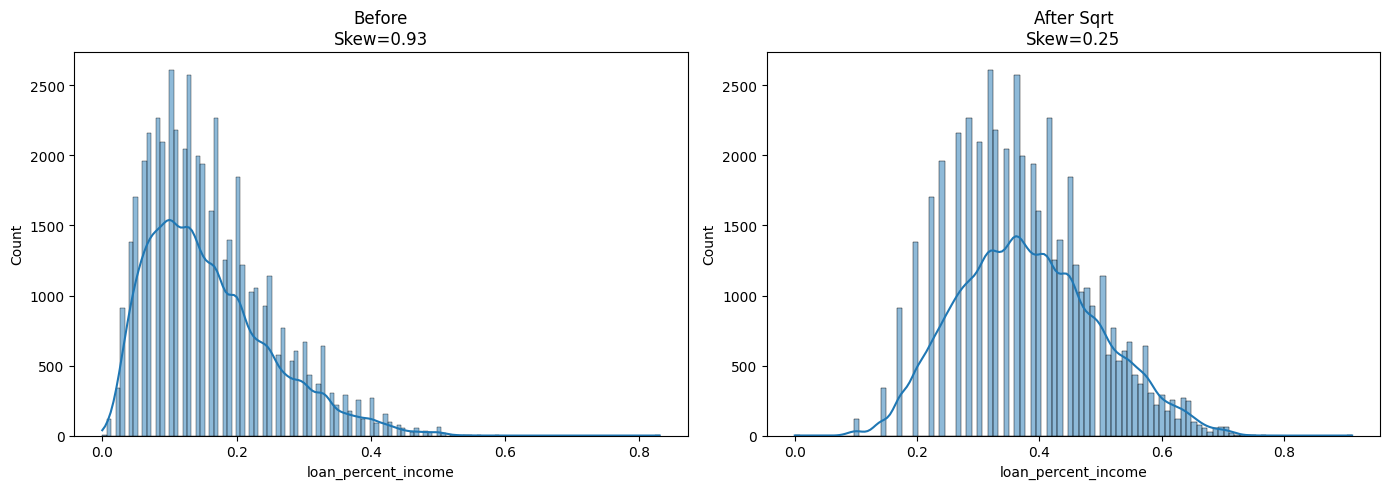

In [60]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(
    X_train['loan_percent_income'],
    kde=True,
    ax=axes[0]
)
axes[0].set_title(
    f'Before\nSkew={X_train["loan_percent_income"].skew():.2f}'
)

sns.histplot(
    X_train_pct['loan_percent_income'],
    kde=True,
    ax=axes[1]
)
axes[1].set_title(
    f'After Sqrt\nSkew={X_train_pct["loan_percent_income"].skew():.2f}'
)

plt.tight_layout()
plt.show()

In [61]:
X_train_cred = X_train.copy()

X_train_cred['cb_person_cred_hist_length'] = np.log1p(X_train_cred['cb_person_cred_hist_length'])


In [62]:
X_train_cred['cb_person_cred_hist_length'].skew()

np.float64(0.4707896417368633)

In [63]:
X_test['cb_person_cred_hist_length'] = np.log1p(X_test['cb_person_cred_hist_length'])

In [64]:
X_test['cb_person_cred_hist_length'].skew()

np.float64(0.46834308137215835)

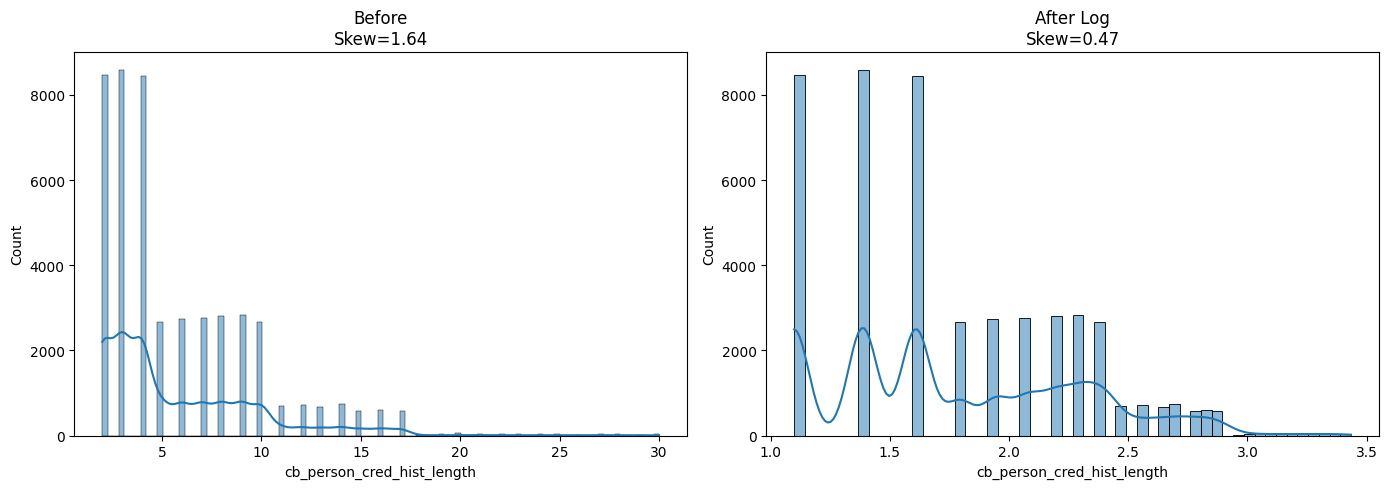

In [65]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(
    X_train['cb_person_cred_hist_length'],
    kde=True,
    ax=axes[0]
)
axes[0].set_title(
    f'Before\nSkew={X_train["cb_person_cred_hist_length"].skew():.2f}'
)

sns.histplot(
    X_train_cred[
        'cb_person_cred_hist_length'
    ],
    kde=True,
    ax=axes[1]
)
axes[1].set_title(
    f'After Log\nSkew={X_train_cred["cb_person_cred_hist_length"].skew():.2f}'
)

plt.tight_layout()
plt.show()

In [66]:
X_train['person_age'] = X_train_age['person_age']
X_train['person_income'] = X_train_income['person_income']
X_train['person_emp_length'] = X_train_emp['person_emp_length']
X_train['loan_amnt'] = X_train_loan['loan_amnt']
X_train['loan_percent_income'] = X_train_pct['loan_percent_income']
X_train['cb_person_cred_hist_length'] = X_train_cred['cb_person_cred_hist_length']

### Categorical Feature

In [67]:
X_train = pd.get_dummies(
    X_train,
    columns=['person_home_ownership'],
    drop_first=True,
    dtype=int
)

In [68]:
X_test = pd.get_dummies(
    X_test,
    columns=['person_home_ownership'],
    drop_first=True,
    dtype=int
)


In [69]:
X_train = pd.get_dummies(
    X_train,
    columns=['loan_intent'],
    drop_first=True,
    dtype=int
)

In [70]:
X_test = pd.get_dummies(
    X_test,
    columns=['loan_intent'],
    drop_first=True,
    dtype=int
)

In [71]:
grade_mapping = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
    'G': 7
}

X_train['loan_grade'] = X_train['loan_grade'].map(grade_mapping)
X_test['loan_grade'] = X_test['loan_grade'].map(grade_mapping)


In [72]:
default_mapping = {
    'Y': 1,
    'N': 0
}

X_train['cb_person_default_on_file'] = (
    X_train['cb_person_default_on_file']
    .map(default_mapping)
)

X_test['cb_person_default_on_file'] = (
    X_test['cb_person_default_on_file']
    .map(default_mapping)
)

In [73]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46916 entries, 14337 to 56422
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   44970 non-null  float64
 1   person_income                46916 non-null  float64
 2   person_emp_length            46407 non-null  float64
 3   loan_grade                   46916 non-null  int64  
 4   loan_amnt                    45273 non-null  float64
 5   loan_int_rate                46916 non-null  float64
 6   loan_percent_income          46916 non-null  float64
 7   cb_person_default_on_file    46916 non-null  int64  
 8   cb_person_cred_hist_length   46916 non-null  float64
 9   person_home_ownership_OTHER  46916 non-null  int64  
 10  person_home_ownership_OWN    46916 non-null  int64  
 11  person_home_ownership_RENT   46916 non-null  int64  
 12  loan_intent_EDUCATION        46916 non-null  int64  
 13  loan_intent_HOMEI

In [74]:
X_train.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
14337,36.0,10.819798,0.0,3,7200.0,13.85,0.374166,1,2.772589,0,0,1,0,1,0,0,0
17117,27.0,10.673619,3.0,3,5000.0,11.66,0.346410,1,2.302585,0,0,1,0,0,0,0,0
32590,25.0,11.156265,0.0,1,8000.0,7.88,0.331662,0,1.386294,0,0,0,1,0,0,0,0
55811,39.0,11.225257,2.0,1,15000.0,6.54,0.447214,0,2.484907,0,0,0,0,0,0,0,0
40120,22.0,10.727685,5.0,1,4000.0,7.66,0.300000,0,1.098612,0,0,1,0,0,1,0,0


In [75]:
X_test.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
4657,23,10.596660,0.0,1,3700,8.00,0.300000,0,1.609438,0,0,1,0,0,1,0,0
56440,25,11.002117,9.0,1,5000,8.59,0.282843,0,1.609438,0,0,0,0,1,0,0,0
42117,32,11.101960,0.0,2,20000,12.53,0.509902,0,1.945910,0,0,1,0,0,1,0,0
10849,22,10.308986,0.0,2,5000,10.59,0.412311,0,1.098612,0,0,1,0,0,0,0,0
39395,27,11.002117,1.0,2,7000,12.21,0.346410,0,2.397895,0,0,1,0,0,1,0,0


In [76]:
X_train.shape

(46916, 17)

In [77]:
X_test.shape

(11729, 17)

# Model

### Hyperparameter Tuning using RandomizedSearchCV (5-Fold Cross-Validation)

In [78]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Model
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Hyperparameter space
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# Randomized Search
xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

# Fit
xgb_search.fit(X_train, y_train)

# Best model prediction
y_pred_xgb = xgb_search.predict(X_test)

# Results
print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest CV F1 Score:")
print(xgb_search.best_score_)

print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Best Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Best CV F1 Score:
0.8108243309783496

Test Accuracy:
0.9530224230539688

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     10087
           1       0.91      0.74      0.81      1642

    accuracy                           0.95     11729
   macro avg       0.94      0.86      0.89     11729
weighted avg       0.95      0.95      0.95     11729



In [79]:
from lightgbm import LGBMClassifier

# Model
lgbm = LGBMClassifier(
    random_state=42
)

# Hyperparameter space
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [-1, 3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50, 70],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

# Randomized Search
lgbm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

# Fit
lgbm_search.fit(X_train, y_train)

# Best model prediction
y_pred_lgbm = lgbm_search.predict(X_test)

# Results
print("Best Parameters:")
print(lgbm_search.best_params_)

print("\nBest CV F1 Score:")
print(lgbm_search.best_score_)

print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred_lgbm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 5367, number of negative: 32166
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027138 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 797
[LightGBM] [Info] Number of data points in the train set: 37533, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.142994 -> initscore=-1.790641
[LightGBM] [Info] Start training from score -1.790641
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [80]:
from sklearn.ensemble import RandomForestClassifier

# Model
rf = RandomForestClassifier(
    random_state=42
)

# Hyperparameter space
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Randomized Search
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

# Fit
rf_search.fit(X_train, y_train)

# Best model prediction
y_pred_rf = rf_search.predict(X_test)

# Results
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV F1 Score:")
print(rf_search.best_score_)

print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 5367, number of negative: 32166
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 802
[LightGBM] [Info] Number of data points in the train set: 37533, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.142994 -> initscore=-1.790641
[LightGBM] [Info] Start training from score -1.790641
[LightGBM] [Info] Number of positive: 5366, number of negative: 32167
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of

Among the evaluated models, LightGBM achieved the best overall performance.
It obtained the highest cross-validation F1-score (0.8128) and the highest
test accuracy (95.31%), while maintaining a strong balance between precision
(0.90) and recall (0.74) for the minority default class. Therefore,
LightGBM was selected as the final model for the loan approval prediction task.

# TEST DATA

In [81]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sushantkr878/loan-approval-prediction-train-data/train (1).csv
/kaggle/input/datasets/sushantkr878/loan-approval-prediction-test-data/test.csv


In [82]:
test = pd.read_csv('/kaggle/input/datasets/sushantkr878/loan-approval-prediction-test-data/test.csv')

In [83]:
test.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,58645,23,69000,RENT,3.0,HOMEIMPROVEMENT,F,25000,15.76,0.36,N,2
1,58646,26,96000,MORTGAGE,6.0,PERSONAL,C,10000,12.68,0.10,Y,4
2,58647,26,30000,RENT,5.0,VENTURE,E,4000,17.19,0.13,Y,2
3,58648,33,50000,RENT,4.0,DEBTCONSOLIDATION,A,7000,8.90,0.14,N,7
4,58649,26,102000,MORTGAGE,8.0,HOMEIMPROVEMENT,D,15000,16.32,0.15,Y,4


In [84]:
test_ids = test['id']

In [85]:
test = test.drop('id', axis=1)

In [86]:
test['person_income'] = np.log1p(test['person_income'])

In [87]:
test = pd.get_dummies(
    test,
    columns=['person_home_ownership'],
    drop_first=True,
    dtype=int
)

In [88]:
test = pd.get_dummies(
    test,
    columns=['loan_intent'],
    drop_first=True,
    dtype=int
)

In [89]:
grade_mapping = {
    'A':1,
    'B':2,
    'C':3,
    'D':4,
    'E':5,
    'F':6,
    'G':7
}

test['loan_grade'] = test['loan_grade'].map(grade_mapping)

In [90]:
test['loan_percent_income'] = np.sqrt(test['loan_percent_income'])

In [91]:
mapping = {'Y':1, 'N':0}

test['cb_person_default_on_file'] = (
    test['cb_person_default_on_file'].map(mapping)
)

In [92]:
test['cb_person_cred_hist_length'] = np.log1p(
    test['cb_person_cred_hist_length']
)

In [93]:
test = test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [94]:
test.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,23,11.141876,3.0,6,25000,15.76,0.600000,0,1.098612,0,0,1,0,1,0,0,0
1,26,11.472114,6.0,3,10000,12.68,0.316228,1,1.609438,0,0,0,0,0,0,1,0
2,26,10.308986,5.0,5,4000,17.19,0.360555,1,1.098612,0,0,1,0,0,0,0,1
3,33,10.819798,4.0,1,7000,8.90,0.374166,0,2.079442,0,0,1,0,0,0,0,0
4,26,11.532738,8.0,4,15000,16.32,0.387298,1,1.609438,0,0,0,0,1,0,0,0


In [95]:
# Predict on test.csv using the best tuned LightGBM model
test_pred = lgbm_search.predict(test)

In [96]:
submission = pd.DataFrame({
    'id'    : test_ids,
    'target': test_pred
})

In [97]:
submission.to_csv('submission.csv', index=False)
print(submission.head())
print(f"\nSubmission shape: {submission.shape}")

      id  target
0  58645       1
1  58646       0
2  58647       1
3  58648       0
4  58649       0

Submission shape: (39098, 2)
